<a href="https://colab.research.google.com/github/navyax7/Data-Analysis-Project/blob/main/Cart_CreditRiskModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Loading the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # panel data
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation

In [ ]:
# read the data file
dataset = pd.read_csv("Churn_Modelling.csv")
# Check is the data is properly loaded
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Separate X and Y
# Remove useless columns and start from CreditScore = 3
# EstimatedSalary is column number 12
# Column number of Exited is 13
# Dataset[rows,columns]
# Stopping = Ending - 1
# what is iloc? Integer Location
# What is role of putting a dot between dataset and iloc?
# () and [] - which bracket should we use?
# Round brackets are used for Tuple and Functions
# Square Brackets are used for Indexing and List
# We need to convert Pandas to numpy array so we use .values
X = dataset.iloc[:,3:13].values
X
y = dataset.iloc[:,13].values
y

array([1, 0, 1, ..., 1, 1, 0])

In [ ]:
# Importing the relevant libraries from sklearn preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# The functionality of LabelEncoder has been transferred to the variable labelencoder
labelencoder = LabelEncoder()
# Here we have applied the function fit_transform on the 2nd column of the data
# What does fit_transform do? Transform the Gender Data by fitting it on the labelencoder
X[:,2] = labelencoder.fit_transform(X[:,2])
# The next step is to label encode the geography
X[:,1] = labelencoder.fit_transform(X[:,1])
X

array([[619, 0, 0, ..., 1, 1, 101348.88],
       [608, 2, 0, ..., 0, 1, 112542.58],
       [502, 0, 0, ..., 1, 0, 113931.57],
       ...,
       [709, 0, 0, ..., 0, 1, 42085.58],
       [772, 1, 1, ..., 1, 0, 92888.52],
       [792, 0, 0, ..., 1, 0, 38190.78]], dtype=object)

Bananas = 0, Mangoes = 1 and Oranges = 2 This is label encoding.

In [ ]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(max_depth=3)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [ ]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.8425


In [ ]:
# Enter the customer details and pass it through clf model
new_customer = clf.predict(np.array([[600,1,1,40,3,60000,2,1,1,50000]])) #not list because cart requires data to be in array
new_customer

array([0])

In [ ]:
!pip install six

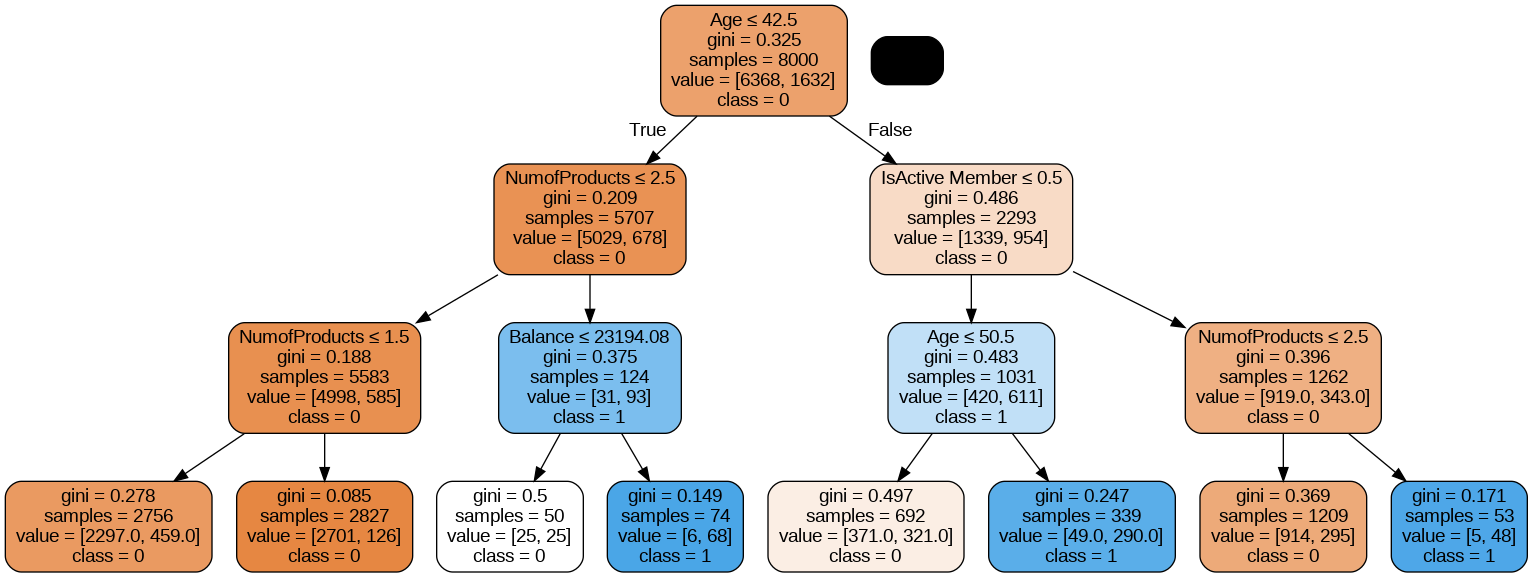

In [ ]:
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus
feature_cols = ["Credit Score","Country", "Gender", "Age","Tenure", "Balance", "NumofProducts", "HasCrCard", "IsActive Member", "Estimated Salary"]
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,feature_names = feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('creditmodel.png')
Image(graph.create_png())

Accuracy: 0.8425


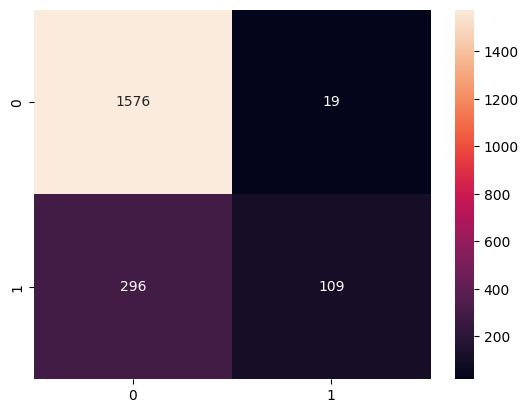

In [ ]:
import seaborn as sns
from sklearn import metrics
# Predicting the Test set results
# Determine if the value is less than or more than the cut-off value
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.45)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt='');

In [ ]:
# Create Bagging model using Decision Trees as base estimator
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(criterion="gini"),
    n_estimators=50,
    random_state=42
)

bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bagging))

Bagging Accuracy: 0.858


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8655


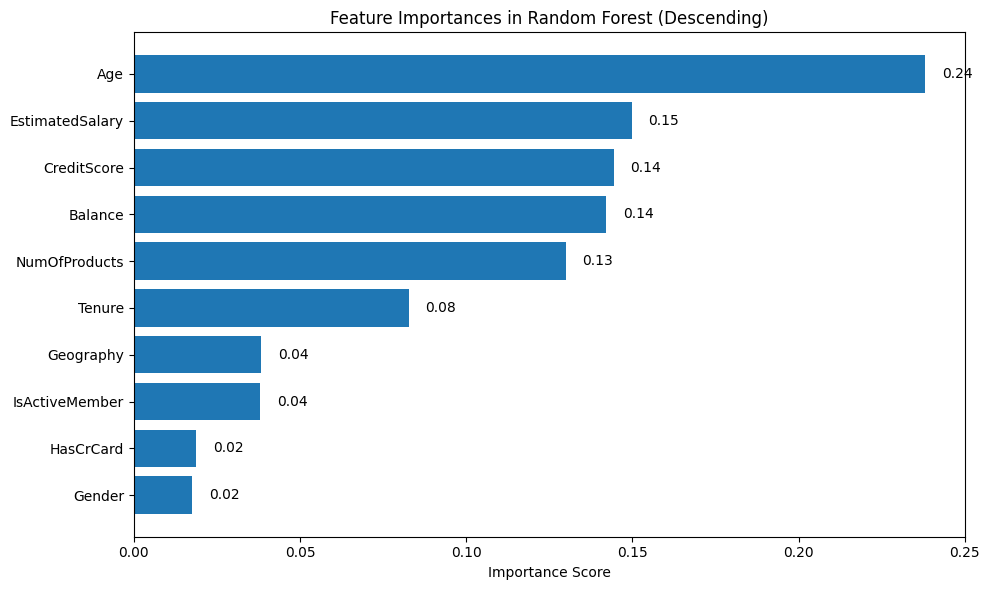

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you have a trained Random Forest model named rf_model
# and X was your feature matrix (after any encoding)

# Feature names (replace with actual column names from your dataset if different)
feature_names = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
                 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

# Get feature importances from the model
importances = rf_model.feature_importances_

# Create a DataFrame to organize and sort
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Importance Score")
plt.title("Feature Importances in Random Forest (Descending)")

# Add value labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}', va='center')

# Reverse the y-axis so most important features are on top
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# OOB is used only on Train Data
# Create the model with OOB enabled
rf_model = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

# Fit the model
rf_model.fit(X_train, y_train)

# Get the OOB score
print("OOB Score:", rf_model.oob_score_)


OOB Score: 0.85725
